In [1]:
from sklearn.model_selection import train_test_split

from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.EvaluationMatrix import EvaluationMatrix

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_cleaned_data_path()
gallstone_dataset.cross_validate_split()

In [3]:
all_train_curves = []
all_val_curves   = []
all_test_scores  = []
trace_metric     = GlobalSetting.evaluation_function

In [4]:
for idx in range(gallstone_dataset.splits):
    x_train , y_train , x_test , y_test = gallstone_dataset.fold_split[idx]
    x_tr , x_val , y_tr , y_val = train_test_split(x_train, y_train,
                                                test_size    = GlobalSetting.test_set_size,
                                                random_state = GlobalSetting.data_split_seed,
                                                stratify     = gallstone_dataset.y_train)

    abc_model = ArtificialBeeColonyElmCV(
        feature_size            = x_tr.shape[1],
        hidden_size             = GlobalSetting.abc_trace_h_size ,
        activation_function     = GlobalSetting.sigmoid,
        regularization_lambda   = GlobalSetting.abc_trace_lambda,
        fitness_function        = trace_metric,
        random_state            = GlobalSetting.abc_trace_seed,
        solution_size           = GlobalSetting.abc_trace_s_size,
        trial_limit             = GlobalSetting.abc_trace_t_size,
        max_iteration           = 25
    )

    abc_model.apply_validation_dataset(x_val, y_val)
    abc_model.fit(x_tr, y_tr)

    val_fitness_curve  = abc_model.val_fitness_curve
    best_fitness_curve = abc_model.convergence_curve
    all_train_curves.append(best_fitness_curve)
    all_val_curves.append(val_fitness_curve)

    abc_model.remove_validation_set()
    abc_model.fit(x_train, y_train)
    y_pred = abc_model.predict(x_test = x_test)
    evaluation_result = EvaluationMatrix(y_true = y_test, y_pred = y_pred)

    final_test_score = evaluation_result.get_all_metrics()[trace_metric]
    all_test_scores.append(final_test_score)

Seed 40  | Iteration 025 complete | Duration: 1.0986s | Scout Triggers: 0 | Best Fitness: 0.847293 | Val Fitness: 0.826124

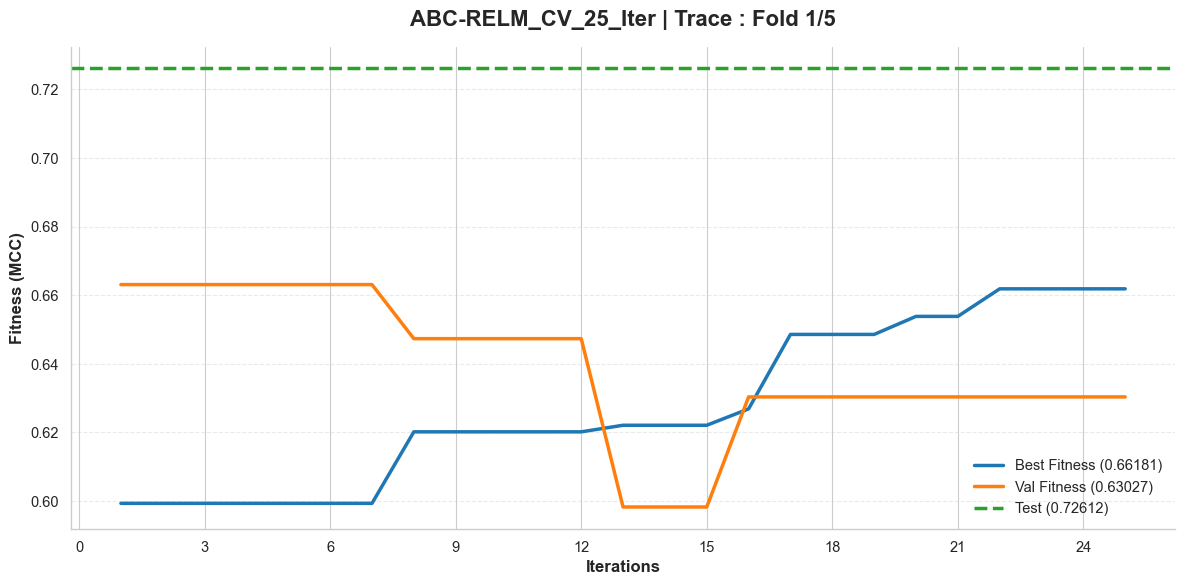

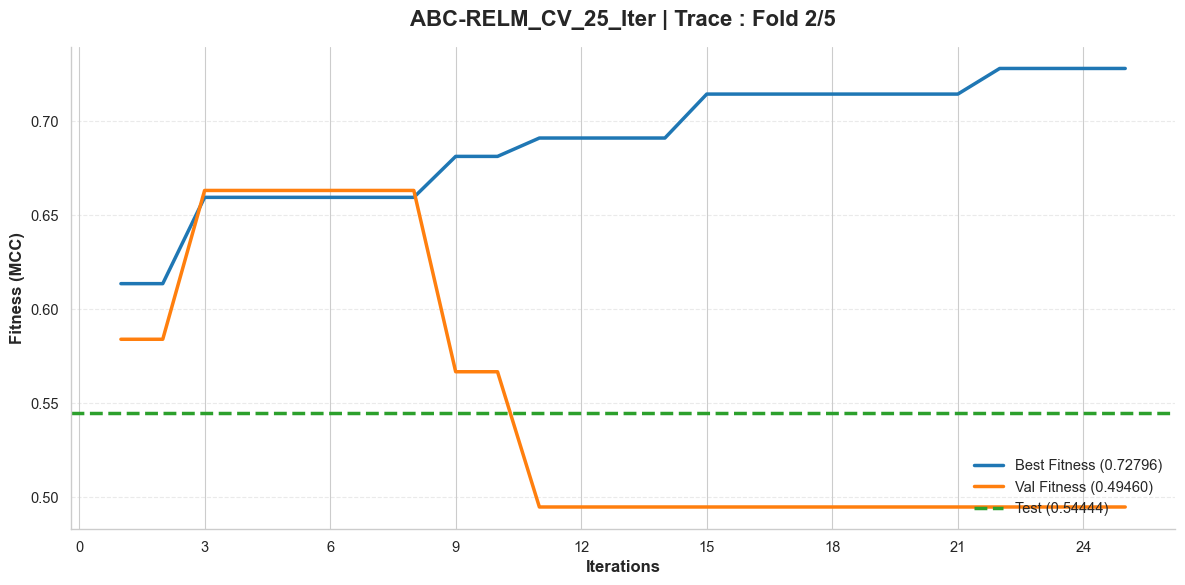

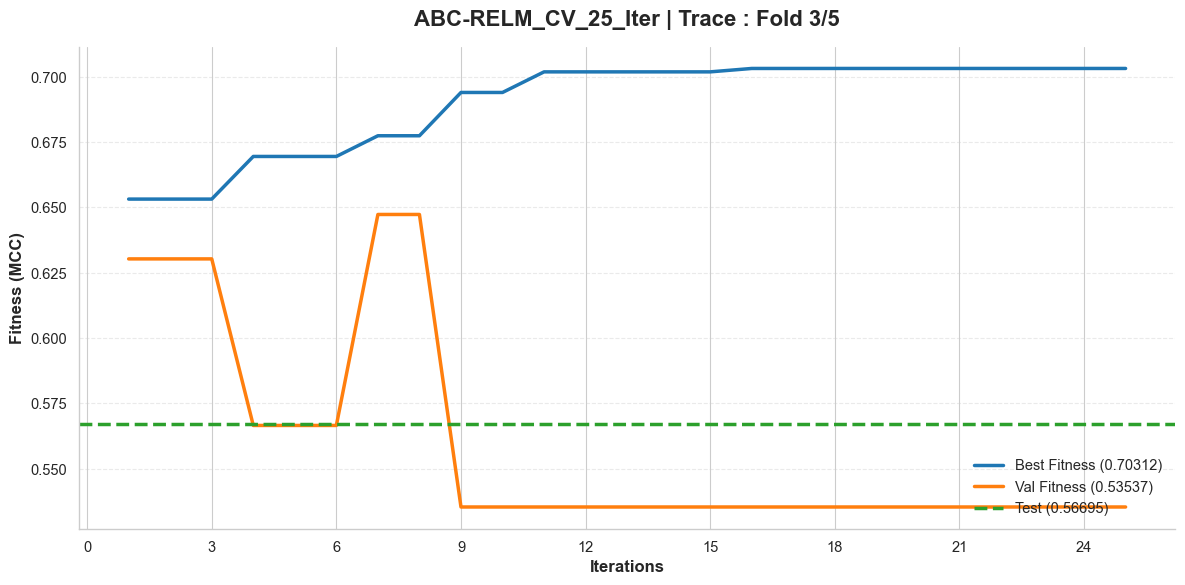

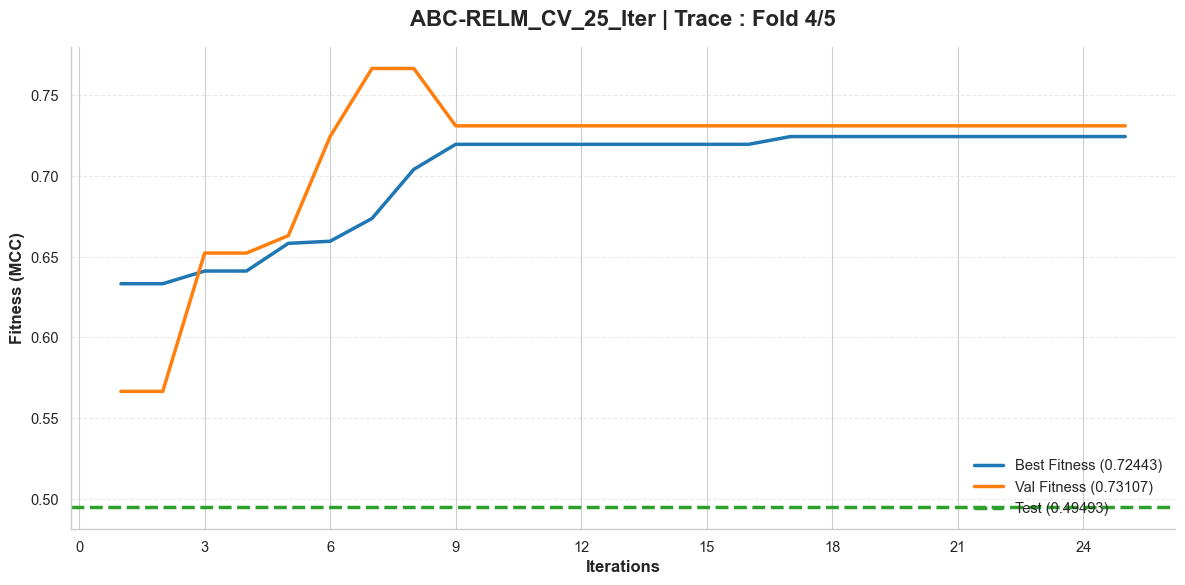

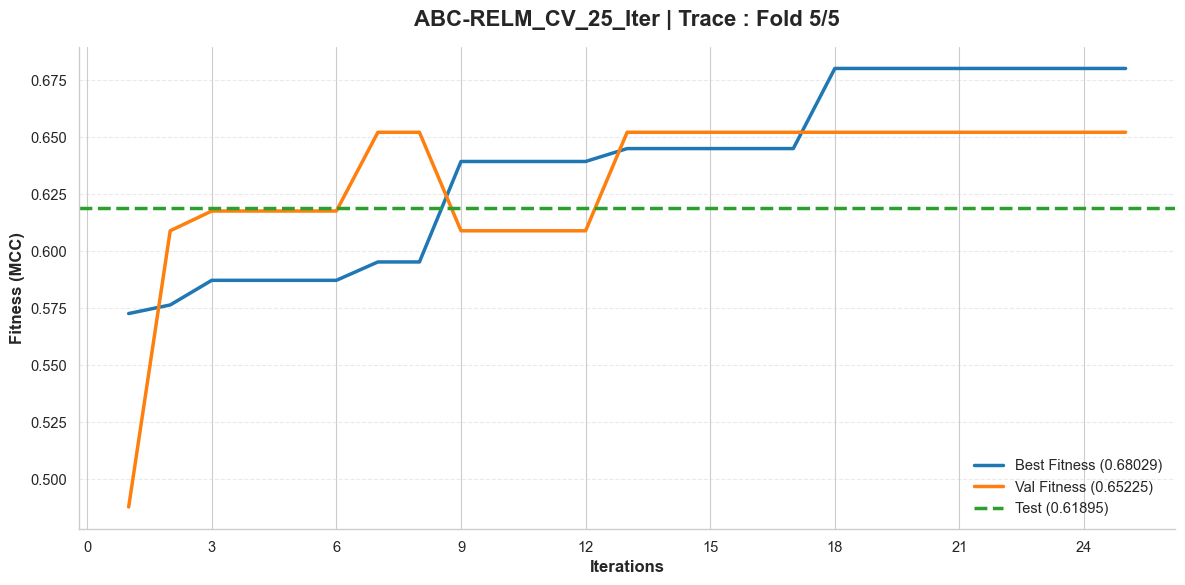

[I/O Trace] Figure exported successfully: ../../Storage/Figure\CV_Aggregate_ABC-RELM_CV_25_Iter_MCC.png


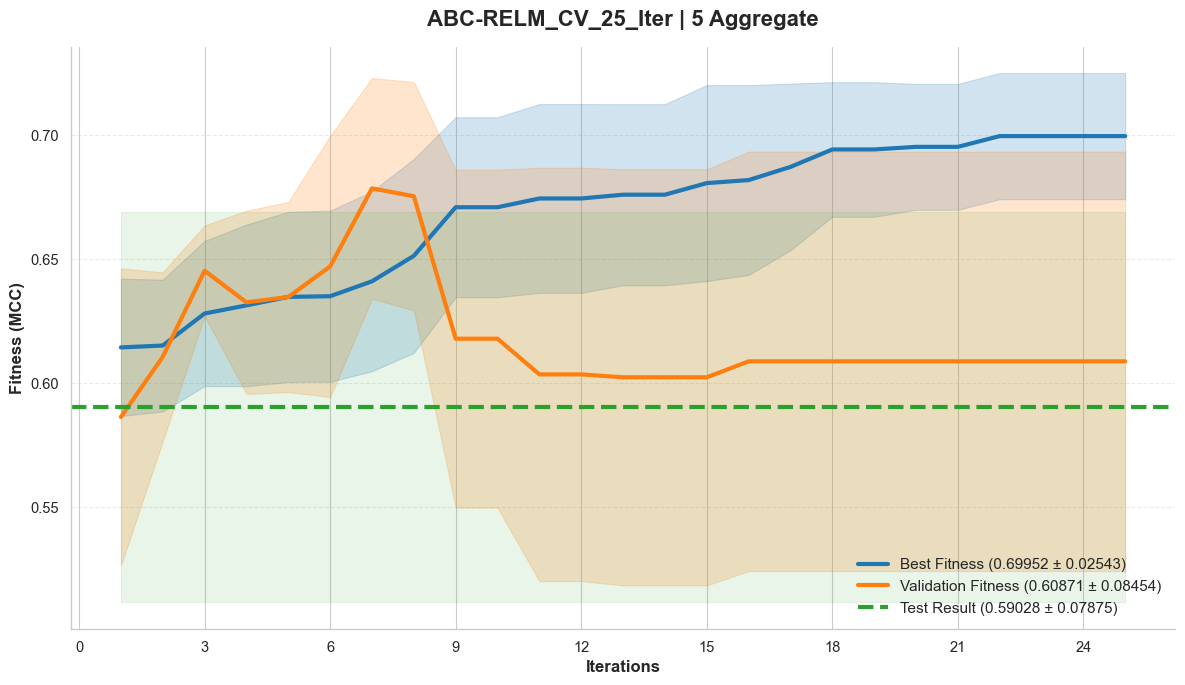

In [5]:
Plotting.plot_cv_grid(
    all_train_curves = all_train_curves,
    all_val_curves   = all_val_curves,
    all_test_scores  = all_test_scores,
    experiment_name  = f"ABC-RELM_CV_25_Iter",
    fitness_metric   = trace_metric,
    is_final_record  = True
)